In [1]:
from scipy.stats import norm, t 
import matplotlib.pyplot as plt
import random
import numpy as np
from rich.console import Console
from rich.table import Table

In [2]:
np.random.seed(42)
random.seed(42)

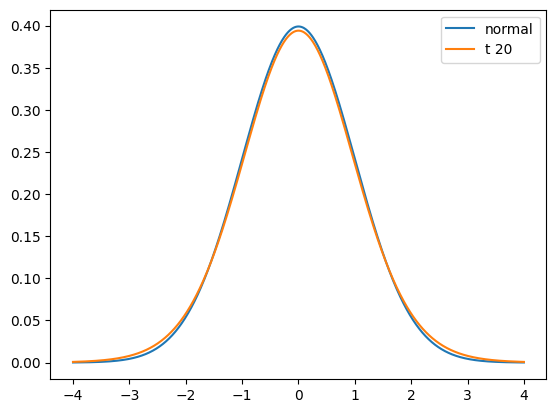

In [3]:
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x), label="normal")
plt.plot(x, t.pdf(x, df = 20), label="t 20")
plt.legend()
plt.show()

In [4]:
# wants P(X > 2)
print("Using CDF")
print("T", 1 - t.cdf(2, df = 20))
print("Normal", 1 - norm.cdf(2))

Using CDF
T 0.02963276772328527
Normal 0.02275013194817921


In [5]:
def calc_prob(X, P):
    total = 0
    n = len(X)
    p = 0
    for i in range(n):
        total += P[i]
        if X[i] > 2:
            p += P[i]
    return p / total
print("Using data")
print("T", calc_prob(x, t.pdf(x, df = 20)))
print("Normal", calc_prob(x, norm.pdf(x)))

Using data
T 0.029188273948070706
Normal 0.02261224040805962


In [ ]:
tables  = [Table(), Table()]
for table in tables:
    table.add_column("Quantile")
    table.add_column("Normal")
    table.add_column("T 20")

for q in (0.9, 0.95, 0.975):
    # print("Q: ", q)
    # print("T", np.quantile(t.pdf(x, df = 20), q = q))
    # print("Normal", np.quantile(norm.pdf(x), q = q))
    # nq = np.quantile(norm.pdf(x), q = q)
    # tq = np.quantile(t.pdf(x, df = 20), q = q)

    ind = int(len(x) * q)
    xq = x[ind]
    
    nq = norm.pdf(xq)
    tq = t.pdf(xq, df = 20)
    row = map(str, (q, nq, tq))
    tables[0].add_row(*row)

    nq = np.quantile(norm.pdf(x), q = q)
    tq = np.quantile(t.pdf(x, df = 20), q = q)
    row = map(str, (q, nq, tq))
    tables[1].add_row(*row)


console = Console()
tables[1].title = "Quantile of probabilities"
console.log(tables[0])
tables[0].title = "Probability of quantile"
console.log(tables[1])


[17:33:43]                  Quantile of probabilities                                              ]8;id=97251;file:///var/folders/0m/wjwgxmxs2xl1pdp5hqg8qgr00000gn/T/ipykernel_46813/3525923573.py\3525923573.py]8;;\:]8;id=398382;file:///var/folders/0m/wjwgxmxs2xl1pdp5hqg8qgr00000gn/T/ipykernel_46813/3525923573.py#30\30]8;;\
           ┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓                                            
           ┃ Quantile ┃ Normal                ┃ T 20                  ┃                                            
           ┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩                                            
           │ 0.9      │ 0.0023296725257150068 │ 0.005049305454427419  │                                            
           │ 0.95     │ 0.0005953537100114529 │ 0.002041047172798491  │                                            
           │ 0.975    │ 0.0002834035558143255 │ 0.0012861077730186043 │                                            
           └──────────┴───────────────────────┴───────────────────────┘                                            

                           Probability of quantile                                                 ]8;id=277370;file:///var/folders/0m/wjwgxmxs2xl1pdp5hqg8qgr00000gn/T/ipykernel_46813/3525923573.py\3525923573.py]8;;\:]8;id=846335;file:///var/folders/0m/wjwgxmxs2xl1pdp5hqg8qgr00000gn/T/ipykernel_46813/3525923573.py#32\32]8;;\
           ┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓                                                
           ┃ Quantile ┃ Normal              ┃ T 20                ┃                                                
           ┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩                                                
           │ 0.9      │ 0.36773640422121634 │ 0.36181952769893855 │                                                
           │ 0.95     │ 0.39074191909301725 │ 0.385498242369079   │                                                
           │ 0.975    │ 0.3969485720092071  │ 0.39192196071191104 │                                                
           └──────────┴─────────────────────┴─────────────────────┘                                                